<a href="https://colab.research.google.com/github/Smolry/Smart-HSRP-detection/blob/main/HSRP_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.5 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model=YOLO('yolov8n-cls.pt')

In [6]:
model.train(data="/content/drive/MyDrive/dataset",epochs=50,imgsz=384,batch=32)

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train22, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a0212feb320>
curves: []
curves_results: []
fitness: 0.9900000095367432
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9800000190734863, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9900000095367432}
save_dir: PosixPath('/content/runs/classify/train22')
speed: {'preprocess': 0.279117570003109, 'inference': 0.5700109700001121, 'loss': 0.00043564499264903134, 'postprocess': 0.0008717949958736426}
task: 'classify'
top1: 0.9800000190734863
top5: 1.0

Index(['epoch', 'time', 'train/loss', 'metrics/accuracy_top1',
       'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


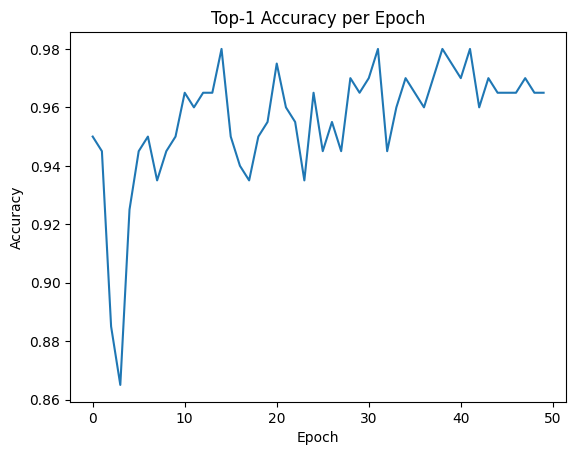

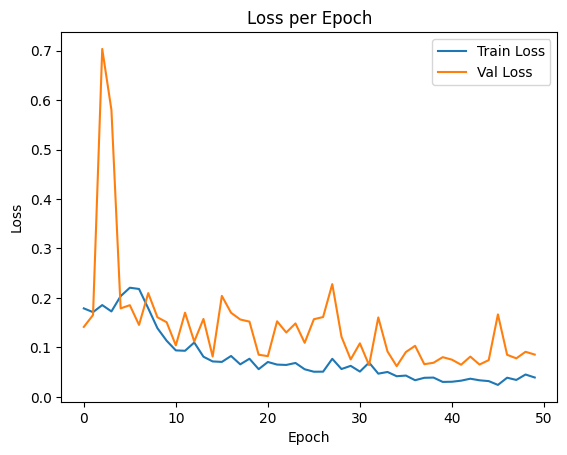

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load training log (adjust path if needed)
results = pd.read_csv("runs/classify/train22/results.csv")

# See what columns are available
print(results.columns)

# Plot Top-1 accuracy over epochs
sns.lineplot(x=results.index, y=results['metrics/accuracy_top1'])
plt.title("Top-1 Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Plot Loss over epochs (if available)
if 'train/loss' in results.columns:
    sns.lineplot(x=results.index, y=results['train/loss'], label="Train Loss")
    if 'val/loss' in results.columns:
        sns.lineplot(x=results.index, y=results['val/loss'], label="Val Loss")
    plt.title("Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

# Plot Fitness per epoch
if 'fitness' in results.columns:
    sns.lineplot(x=results.index, y=results['fitness'])
    plt.title("Fitness per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Fitness")
    plt.show()

In [9]:
from ultralytics import YOLO

model = YOLO("/content/runs/classify/train22/weights/best.pt")


In [12]:
from google.colab import files

uploaded = files.upload()


Saving 5c85a40f-ce81-44b4-82b2-dfdac281217d___new_Skoda-Octavia-1.8-TSI-5.jpg.jpeg to 5c85a40f-ce81-44b4-82b2-dfdac281217d___new_Skoda-Octavia-1.8-TSI-5.jpg.jpeg


In [11]:
results = model.predict("0CKYHOL_lgmnkp83079.jpg", save=True)


print(results[0].probs)



image 1/1 /content/0CKYHOL_lgmnkp83079.jpg: 384x384 hsrp 1.00, non-hsrp 0.00, 2.8ms
Speed: 7.8ms preprocess, 2.8ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 384)
Results saved to /content/runs/classify/predict
ultralytics.engine.results.Probs object with attributes:

data: tensor([1.0000e+00, 8.3882e-12], device='cuda:0')
orig_shape: None
shape: torch.Size([2])
top1: 0
top1conf: tensor(1., device='cuda:0')
top5: [0, 1]
top5conf: tensor([1.0000e+00, 8.3882e-12], device='cuda:0')


In [13]:
results = model.predict("5c85a40f-ce81-44b4-82b2-dfdac281217d___new_Skoda-Octavia-1.8-TSI-5.jpg.jpeg", save=True)


print(results[0].probs)


image 1/1 /content/5c85a40f-ce81-44b4-82b2-dfdac281217d___new_Skoda-Octavia-1.8-TSI-5.jpg.jpeg: 384x384 non-hsrp 1.00, hsrp 0.00, 3.2ms
Speed: 11.9ms preprocess, 3.2ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 384)
Results saved to /content/runs/classify/predict
ultralytics.engine.results.Probs object with attributes:

data: tensor([2.3447e-09, 1.0000e+00], device='cuda:0')
orig_shape: None
shape: torch.Size([2])
top1: 1
top1conf: tensor(1., device='cuda:0')
top5: [1, 0]
top5conf: tensor([1.0000e+00, 2.3447e-09], device='cuda:0')
